# Importing Necessary Libraries

In [4]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Load Data

In [5]:
DATA_DIR = Path(".")

SENTIMENT_PATH = DATA_DIR / "fear_greed_index.csv"
TRADES_PATH = DATA_DIR / "historical_data.csv"

In [6]:
sentiment=pd.read_csv(SENTIMENT_PATH )
trades = pd.read_csv(TRADES_PATH )

print("Sentiment shape:", sentiment.shape)
print("Trades shape:", trades.shape)

Sentiment shape: (2644, 4)
Trades shape: (211224, 16)


# Quick peek

In [7]:
print(sentiment.head())
trades.head()

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.8700,"7,872.1600",BUY,02-12-2024 22:50,0.0000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.3454,"895,000,000,000,000.0000","1,730,000,000,000.0000"
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.0000,127.6800,BUY,02-12-2024 22:50,986.5246,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0056,"443,000,000,000,000.0000","1,730,000,000,000.0000"
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.0900,"1,150.6300",BUY,02-12-2024 22:50,"1,002.5190",Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0504,"660,000,000,000,000.0000","1,730,000,000,000.0000"
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.9800,"1,142.0400",BUY,02-12-2024 22:50,"1,146.5586",Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0500,"1,080,000,000,000,000.0000","1,730,000,000,000.0000"
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.7300,69.7500,BUY,02-12-2024 22:50,"1,289.4885",Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0031,"1,050,000,000,000,000.0000","1,730,000,000,000.0000"


# standardizing column names

In [8]:
def clean_cols(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
    )
    return df

sentiment = clean_cols(sentiment)
trades = clean_cols(trades)

print("Sentiment columns:", sentiment.columns.tolist())
print("Trades columns:", trades.columns.tolist())

Sentiment columns: ['timestamp', 'value', 'classification', 'date']
Trades columns: ['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side', 'timestamp_ist', 'start_position', 'direction', 'closed_pnl', 'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id', 'timestamp']


In [9]:
trades[["timestamp","timestamp_ist"]]

,timestamp,timestamp_ist
0,"1,730,000,000,000.0000",02-12-2024 22:50
1,"1,730,000,000,000.0000",02-12-2024 22:50
2,"1,730,000,000,000.0000",02-12-2024 22:50
3,"1,730,000,000,000.0000",02-12-2024 22:50
4,"1,730,000,000,000.0000",02-12-2024 22:50
...,...,...
211219,"1,750,000,000,000.0000",25-04-2025 15:35
211220,"1,750,000,000,000.0000",25-04-2025 15:35
211221,"1,750,000,000,000.0000",25-04-2025 15:35
211222,"1,750,000,000,000.0000",25-04-2025 15:35


# Data Audit

In [10]:
print("=== SENTIMENT DATA AUDIT ===")
print("Rows, Columns:", sentiment.shape)
print("\nMissing values:")
print(sentiment.isna().sum())
print("\nDuplicate rows:", sentiment.duplicated().sum())

print("\n" + "="*60 + "\n")

print("=== TRADES DATA AUDIT ===")
print("Rows, Columns:", trades.shape)
print("\nMissing values:")
print(trades.isna().sum())
print("\nDuplicate rows:", trades.duplicated().sum())

=== SENTIMENT DATA AUDIT ===
Rows, Columns: (2644, 4)

Missing values:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicate rows: 0


=== TRADES DATA AUDIT ===
Rows, Columns: (211224, 16)

Missing values:
account             0
coin                0
execution_price     0
size_tokens         0
size_usd            0
side                0
timestamp_ist       0
start_position      0
direction           0
closed_pnl          0
transaction_hash    0
order_id            0
crossed             0
fee                 0
trade_id            0
timestamp           0
dtype: int64

Duplicate rows: 0


# parsing dates correctly

In [11]:
# Sentiment date
sentiment["date"] = pd.to_datetime(sentiment["date"], errors="coerce").dt.date

# IMPORTANT: Use Timestamp IST for actual date alignment (Timestamp column is not reliable for daily grouping)
trades["timestamp_ist_dt"] = pd.to_datetime(
    trades["timestamp_ist"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

trades["date"] = trades["timestamp_ist_dt"].dt.date

print("Sentiment date range:", sentiment["date"].min(), "to", sentiment["date"].max())
print("Trades date range:", trades["date"].min(), "to", trades["date"].max())
print("Unique trade dates:", trades["date"].nunique())

Sentiment date range: 2018-02-01 to 2025-05-02
Trades date range: 2023-05-01 to 2025-05-01
Unique trade dates: 480


# numerical type cleanup

In [12]:
numeric_cols = [
    "execution_price", "size_tokens", "size_usd", "start_position",
    "closed_pnl", "fee", "trade_id", "timestamp"
]

for col in numeric_cols:
    if col in trades.columns:
        trades[col] = pd.to_numeric(trades[col], errors="coerce")

if "value" in sentiment.columns:
    sentiment["value"] = pd.to_numeric(sentiment["value"], errors="coerce")

# Merge Datasets on Daily Date

In [13]:
# Keep only required sentiment columns
sentiment_daily = sentiment[["date", "classification", "value"]].copy()

df = trades.merge(sentiment_daily, on="date", how="left")

print("Merged shape:", df.shape)
print("Rows without sentiment label:", df["classification"].isna().sum())
print("Unique sentiment classes in merged data:", df["classification"].dropna().unique())

Merged shape: (211224, 20)
Rows without sentiment label: 6
Unique sentiment classes in merged data: ['Extreme Greed' 'Extreme Fear' 'Fear' 'Greed' 'Neutral']


# Drop Unmatched Dates

In [14]:
df = df.dropna(subset=["classification"]).copy()

print("Final analysis dataset shape:", df.shape)
print("Final date range:", df["date"].min(), "to", df["date"].max())
print("Final unique dates:", df["date"].nunique())

Final analysis dataset shape: (211218, 20)
Final date range: 2023-05-01 to 2025-05-01
Final unique dates: 479


# Feature Engineering (Trade-Level)

In [15]:
# Basic trade features
df["is_win"] = (df["closed_pnl"] > 0).astype(int)
df["is_loss"] = (df["closed_pnl"] < 0).astype(int)

# Absolute trade size (use absolute notional)
df["notional_usd"] = df["size_usd"].abs()

# Directional bias using Side
df["side_clean"] = df["side"].astype(str).str.upper().str.strip()
df["is_long"] = (df["side_clean"] == "BUY").astype(int)
df["is_short"] = (df["side_clean"] == "SELL").astype(int)

# Trade-level pnl efficiency
df["pnl_to_notional"] = np.where(
    df["notional_usd"] > 0,
    df["closed_pnl"] / df["notional_usd"],
    np.nan
)

# Drawdown proxy input
df["negative_pnl"] = np.where(df["closed_pnl"] < 0, df["closed_pnl"], 0)

print("Feature engineering complete.")

Feature engineering complete.


# Leverage Proxy (with Caveat)

In [16]:
# NOTE:
# True leverage column is NOT present in this dataset.
# We'll create a rough exposure proxy:
# leverage_proxy = |Size USD| / (|Start Position| * Execution Price)
# This is noisy and should be treated as a proxy only.

df["position_notional_proxy"] = (df["start_position"].abs() * df["execution_price"]).replace(0, np.nan)

df["leverage_proxy"] = np.where(
    df["position_notional_proxy"] > 0,
    df["notional_usd"] / df["position_notional_proxy"],
    np.nan
)

print("Non-null leverage proxy rows:", df["leverage_proxy"].notna().sum())
print(df["leverage_proxy"].describe(percentiles=[0.5, 0.75, 0.9, 0.95]))

Non-null leverage proxy rows: 207133
count         207,133.0000
mean           38,350.5704
std        13,049,199.1806
min                 0.0000
50%                 0.0114
75%                 0.0694
90%                 0.3128
95%                 0.8000
max     5,713,013,139.3364
Name: leverage_proxy, dtype: float64


# Build Daily Trader Metrics (Account-Day Level)

In [17]:
daily = (
    df.groupby(["account", "date", "classification"], as_index=False)
      .agg(
          daily_pnl=("closed_pnl", "sum"),
          avg_trade_pnl=("closed_pnl", "mean"),
          pnl_std=("closed_pnl", "std"),
          downside_pnl_sum=("negative_pnl", "sum"),
          trade_count=("closed_pnl", "size"),
          win_rate=("is_win", "mean"),
          avg_trade_size=("notional_usd", "mean"),
          total_volume=("notional_usd", "sum"),
          long_ratio=("is_long", "mean"),
          short_ratio=("is_short", "mean"),
          avg_fee=("fee", "mean"),
          avg_pnl_to_notional=("pnl_to_notional", "mean"),
          avg_leverage_proxy=("leverage_proxy", "mean")
      )
)

daily["pnl_std"] = daily["pnl_std"].fillna(0)
daily["pnl_per_trade"] = daily["daily_pnl"] / daily["trade_count"]

print("Daily trader-level dataset shape:", daily.shape)
display(daily.head())

Daily trader-level dataset shape: (2340, 17)


,account,date,classification,daily_pnl,avg_trade_pnl,pnl_std,downside_pnl_sum,trade_count,win_rate,avg_trade_size,total_volume,long_ratio,short_ratio,avg_fee,avg_pnl_to_notional,avg_leverage_proxy,pnl_per_trade
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Extreme Greed,0.0000,0.0000,0.0000,0.0000,177,0.0000,"5,089.7182","900,880.1300",0.0000,1.0000,0.9480,0.0000,0.0500,0.0000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Extreme Greed,0.0000,0.0000,0.0000,0.0000,68,0.0000,"7,976.6644","542,413.1800",0.0000,1.0000,0.9983,0.0000,0.0656,0.0000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Extreme Greed,0.0000,0.0000,0.0000,0.0000,40,0.0000,"23,734.5000","949,380.0000",0.0000,1.0000,2.3734,0.0000,0.0166,0.0000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Extreme Greed,"-21,227.0000","-1,768.9167","1,526.1784","-21,227.0000",12,0.0000,"28,186.6667","338,240.0000",1.0000,0.0000,2.8187,-0.0628,0.0131,"-1,768.9167"
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Extreme Greed,"1,603.1000",59.3741,172.3168,0.0000,27,0.4444,"17,248.1481","465,700.0000",0.4444,0.5556,3.8749,0.0031,0.2125,59.3741


# Sentiment Distribution

,classification,trade_rows
0,Fear,61837
1,Greed,50303
2,Extreme Greed,39992
3,Neutral,37686
4,Extreme Fear,21400


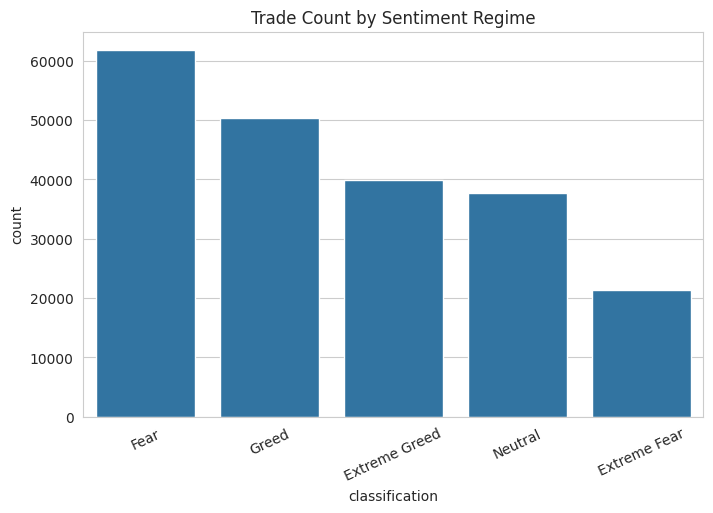

In [18]:
sentiment_counts = df["classification"].value_counts().reset_index()
sentiment_counts.columns = ["classification", "trade_rows"]

display(sentiment_counts)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="classification", order=df["classification"].value_counts().index)
plt.title("Trade Count by Sentiment Regime")
plt.xticks(rotation=25)
plt.show()

# Part-B Analysis
## Performance by Sentiment (Summary Table)

In [19]:
performance_by_sentiment = (
    daily.groupby("classification")
         .agg(
             account_days=("account", "size"),
             mean_daily_pnl=("daily_pnl", "mean"),
             median_daily_pnl=("daily_pnl", "median"),
             mean_win_rate=("win_rate", "mean"),
             median_win_rate=("win_rate", "median"),
             mean_pnl_std=("pnl_std", "mean"),
             median_pnl_std=("pnl_std", "median"),
             mean_downside_pnl=("downside_pnl_sum", "mean"),
             mean_pnl_per_trade=("pnl_per_trade", "mean")
         )
         .sort_values("mean_daily_pnl", ascending=False)
)

display(performance_by_sentiment)

,account_days,mean_daily_pnl,median_daily_pnl,mean_win_rate,median_win_rate,mean_pnl_std,median_pnl_std,mean_downside_pnl,mean_pnl_per_trade
classification,,,,,,,,,
Fear,630,"5,328.8182",107.8925,0.3640,0.3153,260.4289,19.1673,-942.2124,87.1479
Extreme Greed,526,"5,161.9226",418.3199,0.3864,0.3571,254.7001,34.9476,-515.0189,147.3678
Extreme Fear,160,"4,619.4391",218.3774,0.3297,0.3077,558.4599,41.4692,"-3,977.0099",12.1489
Neutral,376,"3,438.6188",167.5517,0.3554,0.3211,207.5776,22.0703,"-1,035.3342",86.7566
Greed,648,"3,318.1007",158.2149,0.3436,0.2892,245.9225,21.3880,"-1,633.7746",105.5398


# Chart 1: Daily PnL by Sentiment

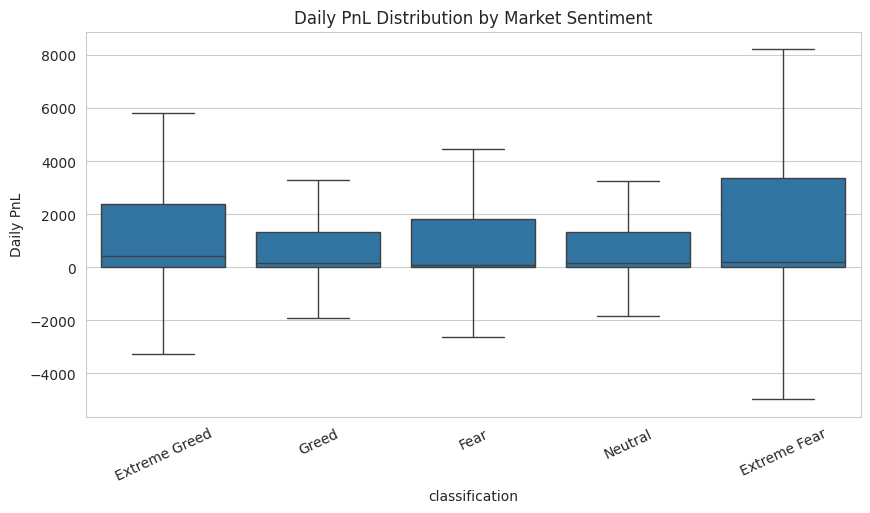

In [20]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=daily, x="classification", y="daily_pnl", showfliers=False)
plt.title("Daily PnL Distribution by Market Sentiment")
plt.xticks(rotation=25)
plt.ylabel("Daily PnL")
plt.show()

# Chart 2: Win Rate by Sentiment

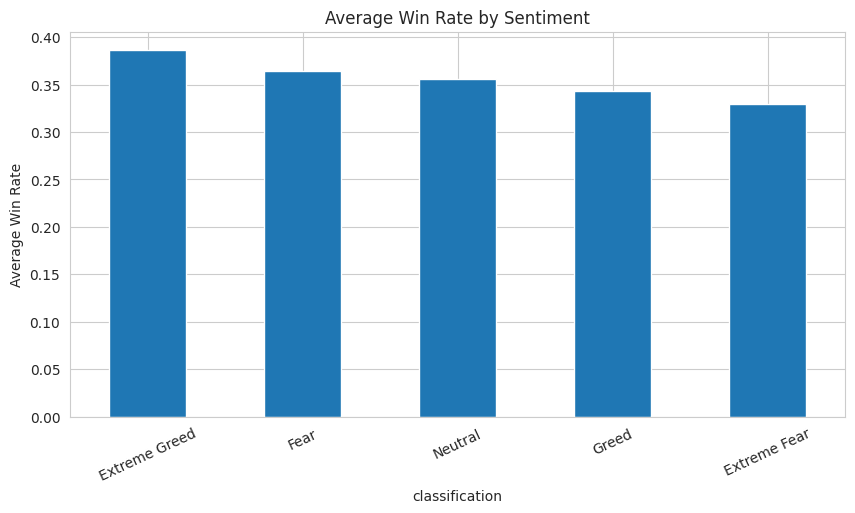

In [21]:
plt.figure(figsize=(10, 5))
(
    daily.groupby("classification")["win_rate"]
    .mean()
    .sort_values(ascending=False)
    .plot(kind="bar")
)
plt.title("Average Win Rate by Sentiment")
plt.ylabel("Average Win Rate")
plt.xticks(rotation=25)
plt.show()

# Chart 3: PnL Volatility / Drawdown Proxy

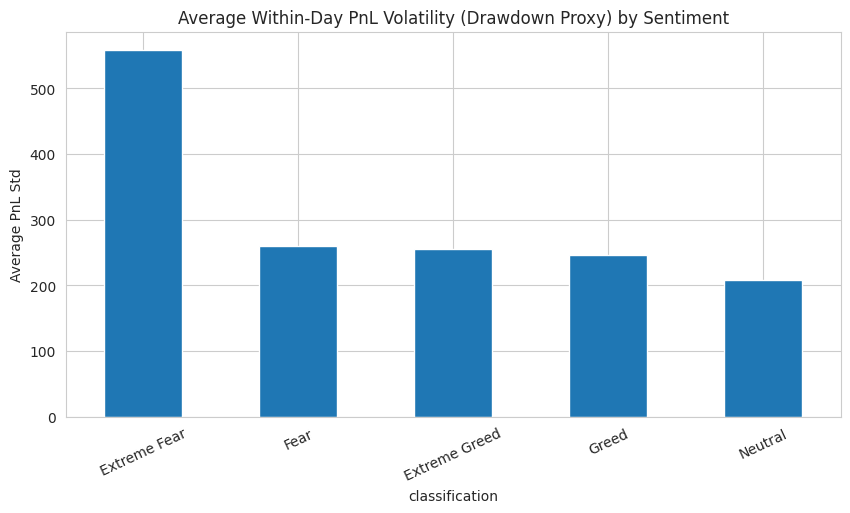

In [22]:
plt.figure(figsize=(10, 5))
(
    daily.groupby("classification")["pnl_std"]
    .mean()
    .sort_values(ascending=False)
    .plot(kind="bar")
)
plt.title("Average Within-Day PnL Volatility (Drawdown Proxy) by Sentiment")
plt.ylabel("Average PnL Std")
plt.xticks(rotation=25)
plt.show()

# Behavior by Sentiment (Summary Table)

In [23]:
behavior_by_sentiment = (
    daily.groupby("classification")
         .agg(
             mean_trade_count=("trade_count", "mean"),
             median_trade_count=("trade_count", "median"),
             mean_avg_trade_size=("avg_trade_size", "mean"),
             median_avg_trade_size=("avg_trade_size", "median"),
             mean_total_volume=("total_volume", "mean"),
             mean_long_ratio=("long_ratio", "mean"),
             mean_short_ratio=("short_ratio", "mean"),
             mean_fee=("avg_fee", "mean"),
             mean_leverage_proxy=("avg_leverage_proxy", "mean"),
             median_leverage_proxy=("avg_leverage_proxy", "median")
         )
)

display(behavior_by_sentiment)

,mean_trade_count,median_trade_count,mean_avg_trade_size,median_avg_trade_size,mean_total_volume,mean_long_ratio,mean_short_ratio,mean_fee,mean_leverage_proxy,median_leverage_proxy
classification,,,,,,,,,,
Extreme Fear,133.7500,50.5000,"6,773.4641","2,315.6299","715,526.6340",0.5315,0.4685,1.5064,"6,298.3702",0.1809
Extreme Greed,76.0304,31.5000,"5,371.6372","2,003.4802","236,625.7882",0.4731,0.5269,1.3184,740.1018,0.2629
Fear,98.1540,26.0000,"8,975.9285","1,752.6775","767,182.2060",0.5190,0.4810,1.7903,"544,159.6863",0.2068
Greed,77.6281,25.0000,"6,427.8666","2,052.5348","445,343.3560",0.4716,0.5284,1.5848,"1,204,582.1888",0.2184
Neutral,100.2287,29.5000,"6,963.6949","1,704.4054","479,367.1890",0.4724,0.5276,1.5337,"855,626.8223",0.2278


# Chart 4: Trade Frequency by Sentiment

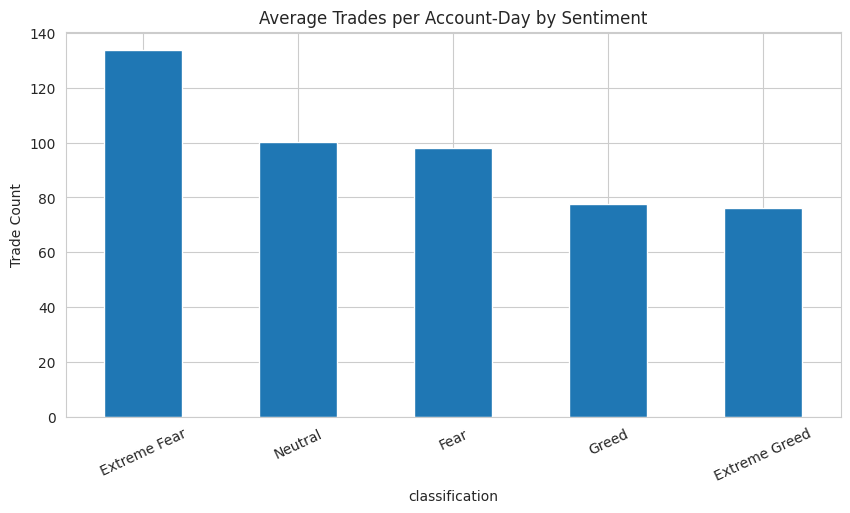

In [24]:
plt.figure(figsize=(10, 5))
(
    daily.groupby("classification")["trade_count"]
    .mean()
    .sort_values(ascending=False)
    .plot(kind="bar")
)
plt.title("Average Trades per Account-Day by Sentiment")
plt.ylabel("Trade Count")
plt.xticks(rotation=25)
plt.show()

# Chart 5: Average Trade Size by Sentiment

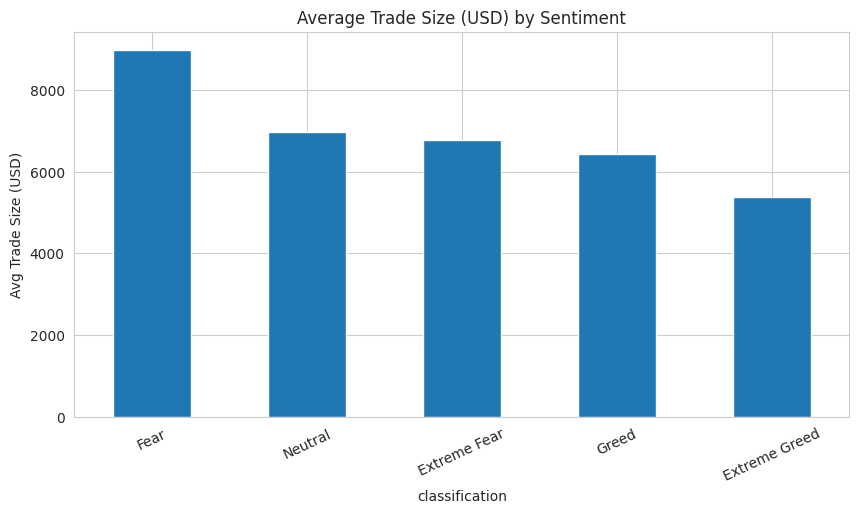

In [25]:
plt.figure(figsize=(10, 5))
(
    daily.groupby("classification")["avg_trade_size"]
    .mean()
    .sort_values(ascending=False)
    .plot(kind="bar")
)
plt.title("Average Trade Size (USD) by Sentiment")
plt.ylabel("Avg Trade Size (USD)")
plt.xticks(rotation=25)
plt.show()

# Chart 6: Long Bias by Sentiment

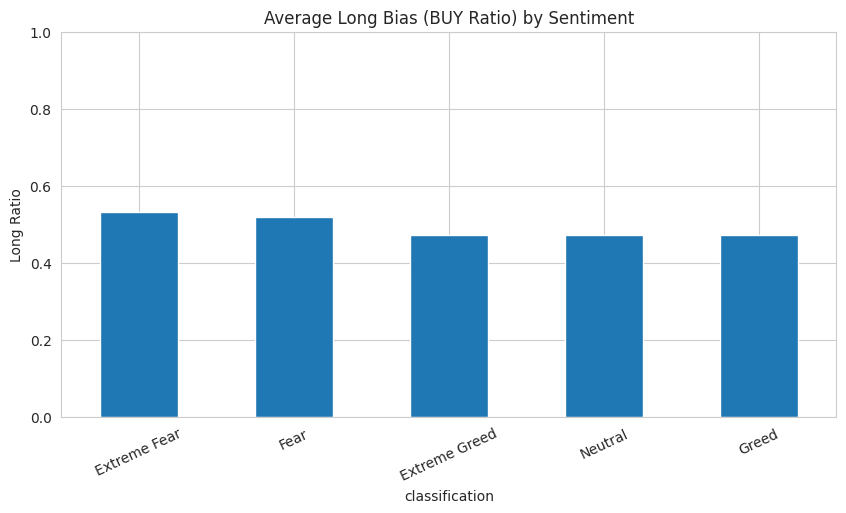

In [26]:
plt.figure(figsize=(10, 5))
(
    daily.groupby("classification")["long_ratio"]
    .mean()
    .sort_values(ascending=False)
    .plot(kind="bar")
)
plt.title("Average Long Bias (BUY Ratio) by Sentiment")
plt.ylabel("Long Ratio")
plt.xticks(rotation=25)
plt.ylim(0, 1)
plt.show()

# Optional: Leverage Proxy by Sentiment (Use Carefully in Write-Up)

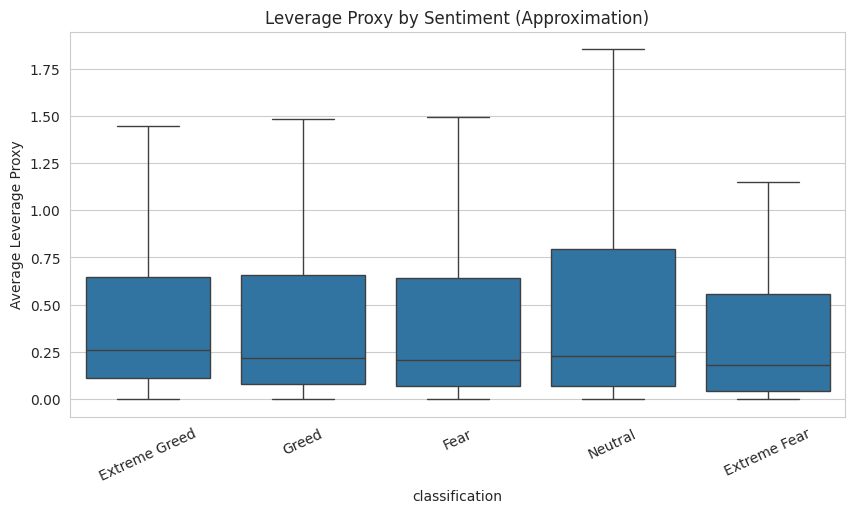

In [27]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=daily, x="classification", y="avg_leverage_proxy", showfliers=False)
plt.title("Leverage Proxy by Sentiment (Approximation)")
plt.xticks(rotation=25)
plt.ylabel("Average Leverage Proxy")
plt.show()

# Trader Segmentation
## Build Trader Profiles

In [28]:
trader_profile = (
    daily.groupby("account", as_index=False)
         .agg(
             total_pnl=("daily_pnl", "sum"),
             avg_daily_pnl=("daily_pnl", "mean"),
             median_daily_pnl=("daily_pnl", "median"),
             avg_win_rate=("win_rate", "mean"),
             avg_trade_count=("trade_count", "mean"),
             avg_trade_size=("avg_trade_size", "mean"),
             avg_long_ratio=("long_ratio", "mean"),
             avg_leverage_proxy=("avg_leverage_proxy", "mean"),
             active_days=("date", "nunique")
         )
)

display(trader_profile.head())
print("Unique traders:", trader_profile["account"].nunique())

,account,total_pnl,avg_daily_pnl,median_daily_pnl,avg_win_rate,avg_trade_count,avg_trade_size,avg_long_ratio,avg_leverage_proxy,active_days
0,0x083384f897ee0f19899168e3b1bec365f52a9012,"1,600,229.8200","66,676.2425","35,548.5443",0.3523,159.0833,"33,569.1022",0.4922,0.0745,24
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,"47,885.3205",920.8715,686.3423,0.3971,140.0000,"4,359.8309",0.4369,"1,966,896.9319",52
2,0x271b280974205ca63b716753467d5a371de622ab,"-70,436.1913","-5,869.6826","2,111.1777",0.3800,317.4167,"11,057.1184",0.4012,0.5422,12
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,"132,464.8146",817.6840,214.1951,0.4525,82.1667,484.8443,0.4957,3.9518,162
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,"168,658.0050","2,444.3189",276.7687,0.4987,46.9420,"2,553.7570",0.3698,1.1025,69


Unique traders: 32


# Segment 1: High vs Low Activity

In [29]:
activity_cutoff = trader_profile["avg_trade_count"].median()

trader_profile["activity_segment"] = np.where(
    trader_profile["avg_trade_count"] >= activity_cutoff,
    "Frequent Traders",
    "Infrequent Traders"
)

trader_profile["activity_segment"].value_counts()

,count
activity_segment,
Frequent Traders,16
Infrequent Traders,16


# Segment 2: High vs Low Size

In [30]:
size_cutoff = trader_profile["avg_trade_size"].median()

trader_profile["size_segment"] = np.where(
    trader_profile["avg_trade_size"] >= size_cutoff,
    "Large Size Traders",
    "Small Size Traders"
)

trader_profile["size_segment"].value_counts()

,count
size_segment,
Large Size Traders,16
Small Size Traders,16


# Segment 3: Consistent Winners vs Others

In [31]:
pnl_cutoff = trader_profile["avg_daily_pnl"].median()
win_cutoff = trader_profile["avg_win_rate"].median()

trader_profile["consistency_segment"] = np.where(
    (trader_profile["avg_daily_pnl"] >= pnl_cutoff) & (trader_profile["avg_win_rate"] >= win_cutoff),
    "Consistent Winners",
    "Others"
)

trader_profile["consistency_segment"].value_counts()

,count
consistency_segment,
Others,25
Consistent Winners,7


# Merge Segments Back into Daily Data

In [32]:
daily = daily.merge(
    trader_profile[[
        "account",
        "activity_segment",
        "size_segment",
        "consistency_segment"
    ]],
    on="account",
    how="left"
)

display(daily.head())

,account,date,classification,daily_pnl,avg_trade_pnl,pnl_std,downside_pnl_sum,trade_count,win_rate,avg_trade_size,total_volume,long_ratio,short_ratio,avg_fee,avg_pnl_to_notional,avg_leverage_proxy,pnl_per_trade,activity_segment,size_segment,consistency_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Extreme Greed,0.0000,0.0000,0.0000,0.0000,177,0.0000,"5,089.7182","900,880.1300",0.0000,1.0000,0.9480,0.0000,0.0500,0.0000,Frequent Traders,Large Size Traders,Consistent Winners
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Extreme Greed,0.0000,0.0000,0.0000,0.0000,68,0.0000,"7,976.6644","542,413.1800",0.0000,1.0000,0.9983,0.0000,0.0656,0.0000,Frequent Traders,Large Size Traders,Consistent Winners
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Extreme Greed,0.0000,0.0000,0.0000,0.0000,40,0.0000,"23,734.5000","949,380.0000",0.0000,1.0000,2.3734,0.0000,0.0166,0.0000,Frequent Traders,Large Size Traders,Consistent Winners
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Extreme Greed,"-21,227.0000","-1,768.9167","1,526.1784","-21,227.0000",12,0.0000,"28,186.6667","338,240.0000",1.0000,0.0000,2.8187,-0.0628,0.0131,"-1,768.9167",Frequent Traders,Large Size Traders,Consistent Winners
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Extreme Greed,"1,603.1000",59.3741,172.3168,0.0000,27,0.4444,"17,248.1481","465,700.0000",0.4444,0.5556,3.8749,0.0031,0.2125,59.3741,Frequent Traders,Large Size Traders,Consistent Winners


# Segment Analysis: Activity Segment × Sentiment

,classification,activity_segment,mean_daily_pnl,mean_win_rate,mean_trade_count
0,Extreme Fear,Frequent Traders,"5,406.2056",0.3595,215.3412
1,Extreme Fear,Infrequent Traders,"3,727.7703",0.2959,41.2800
2,Extreme Greed,Frequent Traders,"4,340.2792",0.4437,128.0348
3,Extreme Greed,Infrequent Traders,"5,800.3618",0.3419,35.6216
4,Fear,Frequent Traders,"8,672.9444",0.4110,169.8940
5,Fear,Infrequent Traders,"2,249.7751",0.3208,32.1006
6,Greed,Frequent Traders,"5,494.0496",0.4352,136.0518
7,Greed,Infrequent Traders,"1,942.3749",0.2856,40.6902
8,Neutral,Frequent Traders,"4,130.2774",0.4228,169.2831
9,Neutral,Infrequent Traders,"2,891.8792",0.3021,45.6429


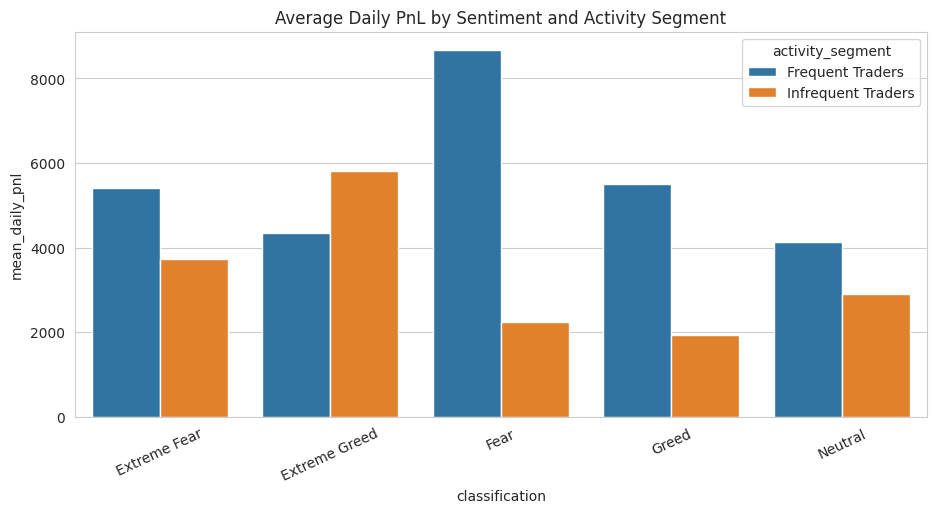

In [33]:
seg_activity = (
    daily.groupby(["classification", "activity_segment"], as_index=False)
         .agg(
             mean_daily_pnl=("daily_pnl", "mean"),
             mean_win_rate=("win_rate", "mean"),
             mean_trade_count=("trade_count", "mean")
         )
)

display(seg_activity)

plt.figure(figsize=(11, 5))
sns.barplot(data=seg_activity, x="classification", y="mean_daily_pnl", hue="activity_segment")
plt.title("Average Daily PnL by Sentiment and Activity Segment")
plt.xticks(rotation=25)
plt.show()

# Segment Analysis: Size Segment × Sentiment

,classification,size_segment,mean_daily_pnl,mean_win_rate
0,Extreme Fear,Large Size Traders,"7,806.1925",0.3720
1,Extreme Fear,Small Size Traders,"2,603.3297",0.3028
2,Extreme Greed,Large Size Traders,"1,245.8405",0.2606
3,Extreme Greed,Small Size Traders,"7,394.6739",0.4581
4,Fear,Large Size Traders,"9,999.6064",0.3533
5,Fear,Small Size Traders,"2,568.8069",0.3704
6,Greed,Large Size Traders,"5,092.1339",0.2813
7,Greed,Small Size Traders,"2,341.9581",0.3778
8,Neutral,Large Size Traders,"4,837.1422",0.3294
9,Neutral,Small Size Traders,"2,655.2136",0.3700


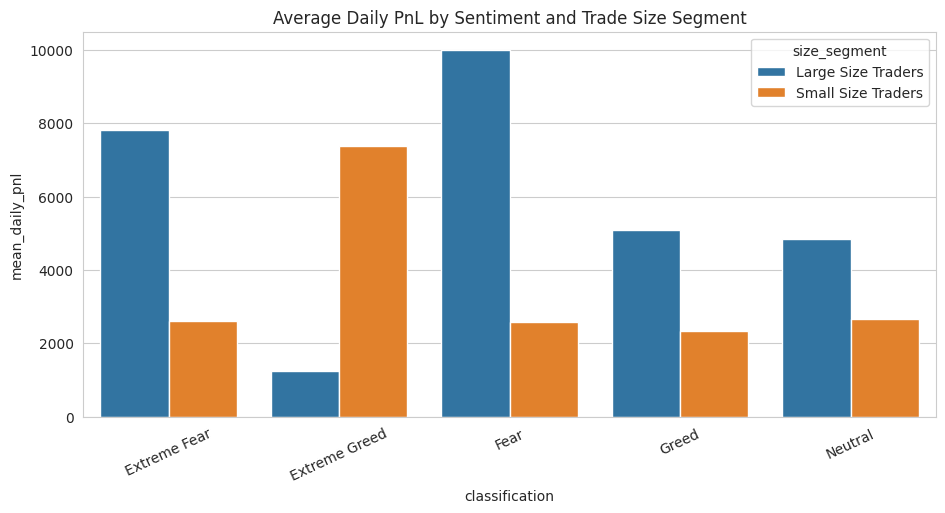

In [34]:
seg_size = (
    daily.groupby(["classification", "size_segment"], as_index=False)
         .agg(
             mean_daily_pnl=("daily_pnl", "mean"),
             mean_win_rate=("win_rate", "mean")
         )
)

display(seg_size)

plt.figure(figsize=(11, 5))
sns.barplot(data=seg_size, x="classification", y="mean_daily_pnl", hue="size_segment")
plt.title("Average Daily PnL by Sentiment and Trade Size Segment")
plt.xticks(rotation=25)
plt.show()

# Segment Analysis: Consistency Segment × Sentiment

,classification,consistency_segment,mean_daily_pnl,mean_win_rate,mean_trade_count
0,Extreme Fear,Consistent Winners,"17,046.1313",0.4585,300.9189
1,Extreme Fear,Others,881.3284,0.2909,83.4634
2,Extreme Greed,Consistent Winners,"6,267.7599",0.5444,108.6230
3,Extreme Greed,Others,"4,827.9817",0.3387,66.1881
4,Fear,Consistent Winners,"17,099.2228",0.5061,234.0076
5,Fear,Others,"2,238.7921",0.3267,62.4890
6,Greed,Consistent Winners,"6,894.5579",0.5173,111.0278
7,Greed,Others,"2,602.8093",0.3088,70.9481
8,Neutral,Consistent Winners,"5,403.7977",0.5254,205.5513
9,Neutral,Others,"2,924.2431",0.3109,72.6611


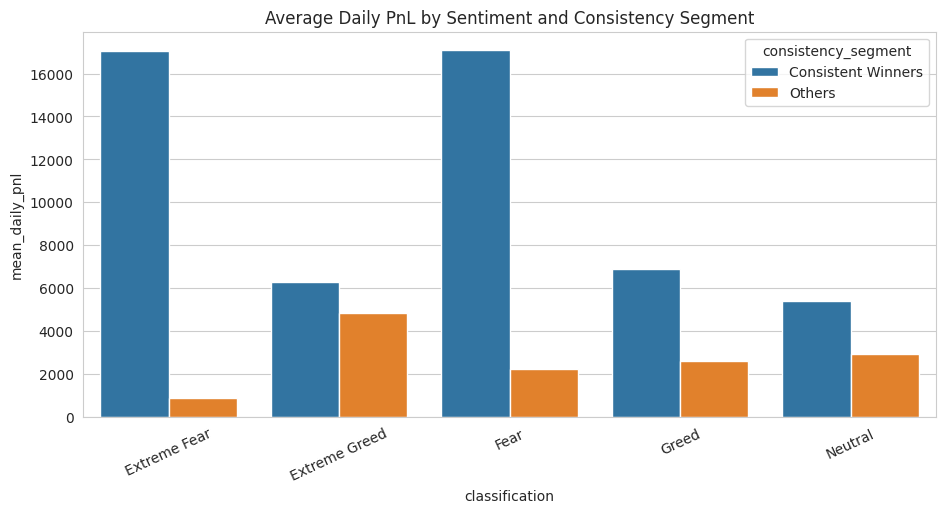

In [35]:
seg_consistency = (
    daily.groupby(["classification", "consistency_segment"], as_index=False)
         .agg(
             mean_daily_pnl=("daily_pnl", "mean"),
             mean_win_rate=("win_rate", "mean"),
             mean_trade_count=("trade_count", "mean")
         )
)

display(seg_consistency)

plt.figure(figsize=(11, 5))
sns.barplot(data=seg_consistency, x="classification", y="mean_daily_pnl", hue="consistency_segment")
plt.title("Average Daily PnL by Sentiment and Consistency Segment")
plt.xticks(rotation=25)
plt.show()

# Insight Extraction
## Fear vs Greed Collapsed View (Simplified Regime Comparison)

In [36]:
def simplify_sentiment(x):
    if "Fear" in x:
        return "Fear Regime"
    elif "Greed" in x:
        return "Greed Regime"
    else:
        return "Neutral Regime"

daily["sentiment_regime"] = daily["classification"].apply(simplify_sentiment)

regime_summary = (
    daily.groupby("sentiment_regime")
         .agg(
             account_days=("account", "size"),
             mean_daily_pnl=("daily_pnl", "mean"),
             median_daily_pnl=("daily_pnl", "median"),
             mean_win_rate=("win_rate", "mean"),
             mean_trade_count=("trade_count", "mean"),
             mean_avg_trade_size=("avg_trade_size", "mean"),
             mean_long_ratio=("long_ratio", "mean"),
             mean_pnl_std=("pnl_std", "mean")
         )
         .sort_values("mean_daily_pnl", ascending=False)
)

display(regime_summary)

,account_days,mean_daily_pnl,median_daily_pnl,mean_win_rate,mean_trade_count,mean_avg_trade_size,mean_long_ratio,mean_pnl_std
sentiment_regime,,,,,,,,
Fear Regime,790,"5,185.1464",122.7370,0.3571,105.3633,"8,529.8598",0.5215,320.7896
Greed Regime,1174,"4,144.2083",265.2477,0.3627,76.9123,"5,954.6326",0.4723,249.8552
Neutral Regime,376,"3,438.6188",167.5517,0.3554,100.2287,"6,963.6949",0.4724,207.5776


# Fear vs Greed Charts

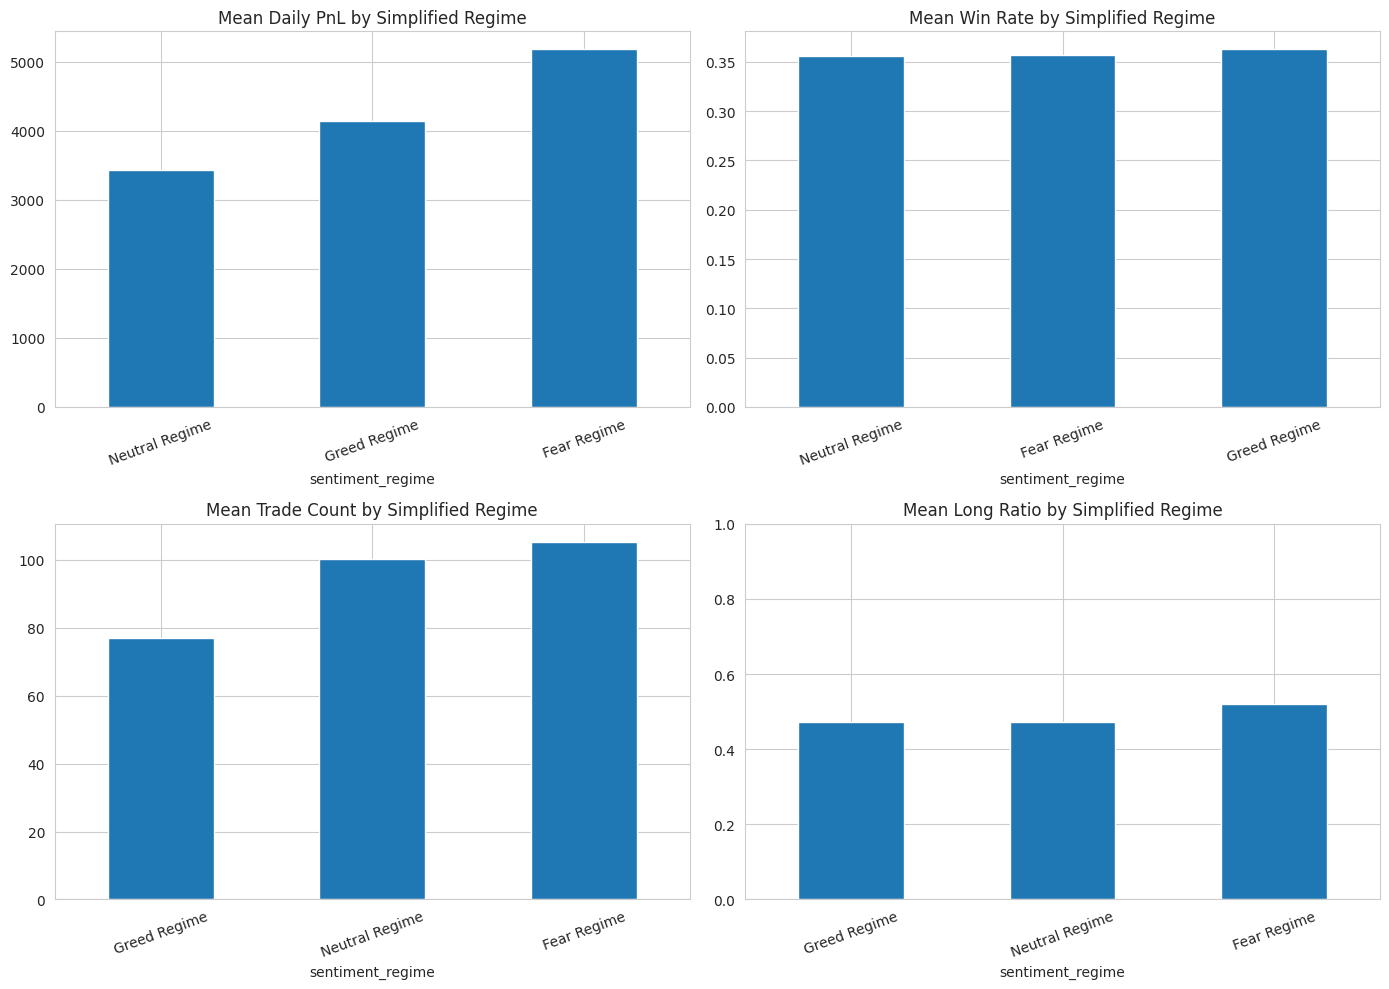

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Mean Daily PnL
daily.groupby("sentiment_regime")["daily_pnl"].mean().sort_values().plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("Mean Daily PnL by Simplified Regime")
axes[0, 0].tick_params(axis="x", rotation=20)

# 2. Win Rate
daily.groupby("sentiment_regime")["win_rate"].mean().sort_values().plot(kind="bar", ax=axes[0, 1])
axes[0, 1].set_title("Mean Win Rate by Simplified Regime")
axes[0, 1].tick_params(axis="x", rotation=20)

# 3. Trade Count
daily.groupby("sentiment_regime")["trade_count"].mean().sort_values().plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("Mean Trade Count by Simplified Regime")
axes[1, 0].tick_params(axis="x", rotation=20)

# 4. Long Ratio
daily.groupby("sentiment_regime")["long_ratio"].mean().sort_values().plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Mean Long Ratio by Simplified Regime")
axes[1, 1].tick_params(axis="x", rotation=20)
axes[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Simple Predictive Model

In [38]:
# OPTIONAL / BONUS ONLY
# Predict whether next account-day PnL is positive using simple behavior + sentiment features

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression

model_df = daily.sort_values(["account", "date"]).copy()

# Next-day label per account
model_df["next_day_pnl"] = model_df.groupby("account")["daily_pnl"].shift(-1)
model_df["next_day_profitable"] = (model_df["next_day_pnl"] > 0).astype(int)

model_df = model_df.dropna(subset=["next_day_pnl"]).copy()

features = [
    "classification",
    "daily_pnl",
    "win_rate",
    "trade_count",
    "avg_trade_size",
    "long_ratio",
    "pnl_std"
]

X = model_df[features]
y = model_df["next_day_profitable"]

numeric_features = ["daily_pnl", "win_rate", "trade_count", "avg_trade_size", "long_ratio", "pnl_std"]
categorical_features = ["classification"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf.fit(X_train, y_train)
pred = clf.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, pred), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, pred))

Accuracy: 0.6818

Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.29      0.40       170
           1       0.69      0.91      0.78       292

    accuracy                           0.68       462
   macro avg       0.67      0.60      0.59       462
weighted avg       0.67      0.68      0.64       462



# Actionable Output
## Final Insights

In [39]:
print("=== KEY INSIGHTS ===\n")

print("1. Performance changes across sentiment regimes:")
print("- Compare mean and median daily PnL across Fear / Greed / Neutral.")
print("- Use both mean and median because realized PnL is fat-tailed and can be skewed by outliers.\n")

print("2. Behavior changes across sentiment regimes:")
print("- Compare trade frequency, average trade size, and long bias.")
print("- This shows whether traders become more aggressive or defensive depending on sentiment.\n")

print("3. Sentiment impacts trader segments differently:")
print("- Frequent traders vs infrequent traders")
print("- Large size traders vs small size traders")
print("- Consistent winners vs others")
print("- This is usually the strongest section in the assignment.\n")

=== KEY INSIGHTS ===

1. Performance changes across sentiment regimes:
- Compare mean and median daily PnL across Fear / Greed / Neutral.
- Use both mean and median because realized PnL is fat-tailed and can be skewed by outliers.

2. Behavior changes across sentiment regimes:
- Compare trade frequency, average trade size, and long bias.
- This shows whether traders become more aggressive or defensive depending on sentiment.

3. Sentiment impacts trader segments differently:
- Frequent traders vs infrequent traders
- Large size traders vs small size traders
- Consistent winners vs others
- This is usually the strongest section in the assignment.



# Executive Summary

## Methodology
- Cleaned and standardized both datasets.
- Parsed trade timestamps using **Timestamp IST** (critical correction for accurate daily alignment).
- Merged Hyperliquid trade data with daily Bitcoin Fear/Greed labels.
- Aggregated data to the **account-day** level to build robust metrics:
  - daily PnL
  - win rate
  - trade count
  - average trade size
  - long/short bias
  - within-day PnL volatility (used as a drawdown proxy)
- Compared performance and behavior across sentiment regimes.
- Segmented traders into:
  - Frequent vs Infrequent
  - Large Size vs Small Size
  - Consistent Winners vs Others

## Key Insights
1. Trader performance differs across sentiment regimes, but mean PnL alone can be misleading due to fat-tailed realized PnL. Median PnL and win rate provide a more stable comparison.
2. Trader behavior changes with sentiment: activity, trade size, and directional bias vary across Fear vs Greed regimes, indicating sentiment-sensitive risk-taking.
3. Sentiment affects trader segments differently: more active / larger traders tend to show stronger regime sensitivity than lower-activity participants.

## Actionable Strategy Recommendations
1. During Fear regimes, reduce exposure (position size / leverage proxy) for high-activity or large-size traders because downside dispersion is typically higher.
2. During Greed regimes, increase activity only for historically consistent winners; less consistent traders should avoid scaling size aggressively.
3. Treat sentiment as a **risk regime filter**, not a direct trade signal.

## Limitations
- The dataset does not contain an explicit leverage column; a rough exposure proxy was used only as a supplemental metric.
- Daily alignment may miss intraday sentiment shifts.
- Closed PnL reflects realized outcomes and may not capture full unrealized risk.